# TensorFlow

LSTM (Long Short-Term Memory),

We will explore two new architectures, Stacked LSTM and Bidirectional LSTM on the MNIST dataset. We will also compare the results with the RNN architecture we built in the previous notebook.

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
# scale the pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [4]:
# create the models
import keras.layers as layers

model_stacked = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_bidirectional = keras.models.Sequential([
    layers.InputLayer(shape=(28, 28)),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

2026-03-16 10:52:02.976103: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-16 10:52:02.976137: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-16 10:52:02.976146: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-16 10:52:02.976166: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-16 10:52:02.976179: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
# print model summaries
model_stacked.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 28, 64)         │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,986 (152.29 KB)

 Trainable params: 38,986 (152.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model_bidirectional.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        47,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,522 (220.79 KB)

 Trainable params: 56,522 (220.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# compile the models
LEARNING_RATE = 0.001
BATCH_SIZE = 128
EPOCHS = 25

# callback for early stopping
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_stacked.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

model_bidirectional.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

In [8]:
# fit the stacked LSTM model
history_stacked = model_stacked.fit(X_train, y_train,
                                    validation_data=(X_test, y_test),
                                    epochs=EPOCHS,
                                    batch_size=BATCH_SIZE,
                                    callbacks=[early_stopping])

Epoch 1/25


2026-03-16 10:52:28.343955: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7861 - loss: 0.6576 - val_accuracy: 0.9290 - val_loss: 0.2397
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9408 - loss: 0.1990 - val_accuracy: 0.9551 - val_loss: 0.1484
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9590 - loss: 0.1371 - val_accuracy: 0.9672 - val_loss: 0.1102
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9679 - loss: 0.1079 - val_accuracy: 0.9670 - val_loss: 0.1093
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9743 - loss: 0.0857 - val_accuracy: 0.9760 - val_loss: 0.0782
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9793 - loss: 0.0706 - val_accuracy: 0.9739 - val_loss: 0.0818
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9816 - loss: 0.0609 - val_accuracy: 0.9773 - val_loss: 0.0750
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9837 - loss: 0.0525 - val_accuracy: 0.979

In [9]:
# fit the bidirectional LSTM model
history_bidirectional = model_bidirectional.fit(X_train, y_train,
                                                validation_data=(X_test, y_test),
                                                epochs=EPOCHS,
                                                batch_size=BATCH_SIZE,
                                                callbacks=[early_stopping])

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.8256 - loss: 0.5351 - val_accuracy: 0.9360 - val_loss: 0.2017
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9525 - loss: 0.1516 - val_accuracy: 0.9618 - val_loss: 0.1205
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9653 - loss: 0.1085 - val_accuracy: 0.9706 - val_loss: 0.0915


In [10]:
# evaluate the models on the test set
test_loss_stacked, test_acc_stacked = model_stacked.evaluate(X_test, y_test)
print(f'Stacked LSTM Test accuracy: {test_acc_stacked:.4f}')

test_loss_bidirectional, test_acc_bidirectional = model_bidirectional.evaluate(X_test, y_test)
print(f'Bidirectional LSTM Test accuracy: {test_acc_bidirectional:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9848 - loss: 0.0513
Stacked LSTM Test accuracy: 0.9848
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9360 - loss: 0.2017
Bidirectional LSTM Test accuracy: 0.9360


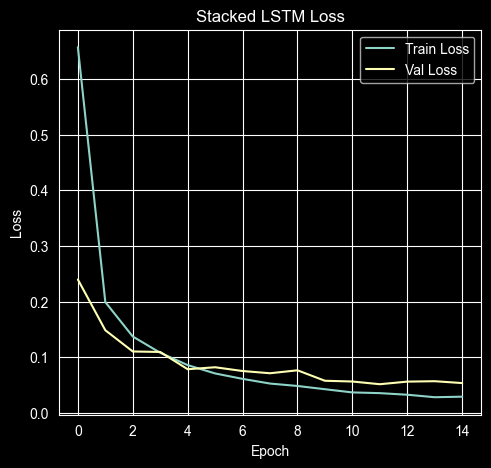

In [11]:
# display the loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_stacked.history['loss'], label='Train Loss')
plt.plot(history_stacked.history['val_loss'], label='Val Loss')
plt.title('Stacked LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

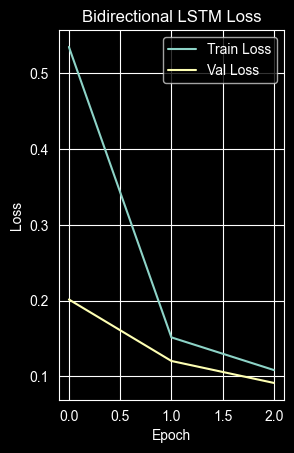

In [12]:
# display the loss curves for the bidirectional LSTM
plt.subplot(1, 2, 2)
plt.plot(history_bidirectional.history['loss'], label='Train Loss')
plt.plot(history_bidirectional.history['val_loss'], label='Val Loss')
plt.title('Bidirectional LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


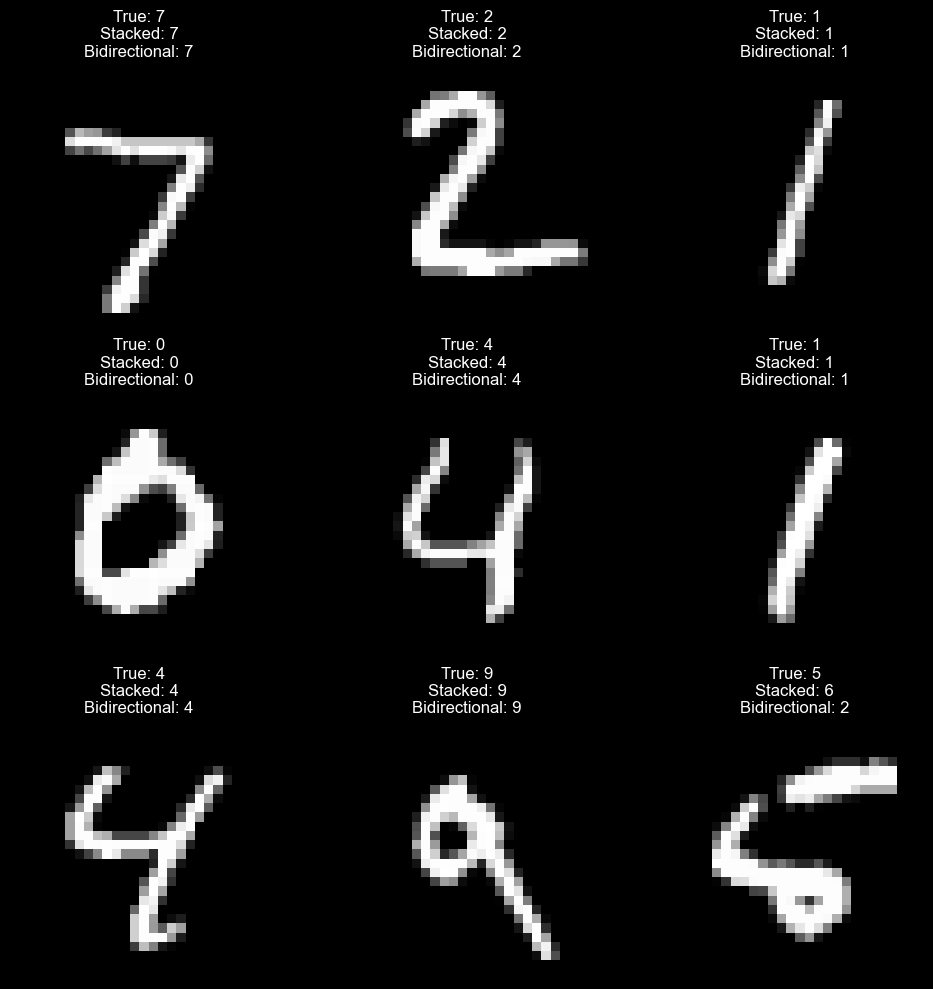

In [13]:
# take 3 x 3 grid of examples from the test set and display the true label + predicted label for each model
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
pred_stacked = model_stacked.predict(X_test)
pred_bidirectional = model_bidirectional.predict(X_test)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    true_label = y_test[i]
    pred_label_stacked = np.argmax(pred_stacked[i])
    pred_label_bidirectional = np.argmax(pred_bidirectional[i])
    ax.set_title(f'True: {true_label}\nStacked: {pred_label_stacked}\nBidirectional: {pred_label_bidirectional}')
    ax.axis('off')
plt.tight_layout()
plt.show()

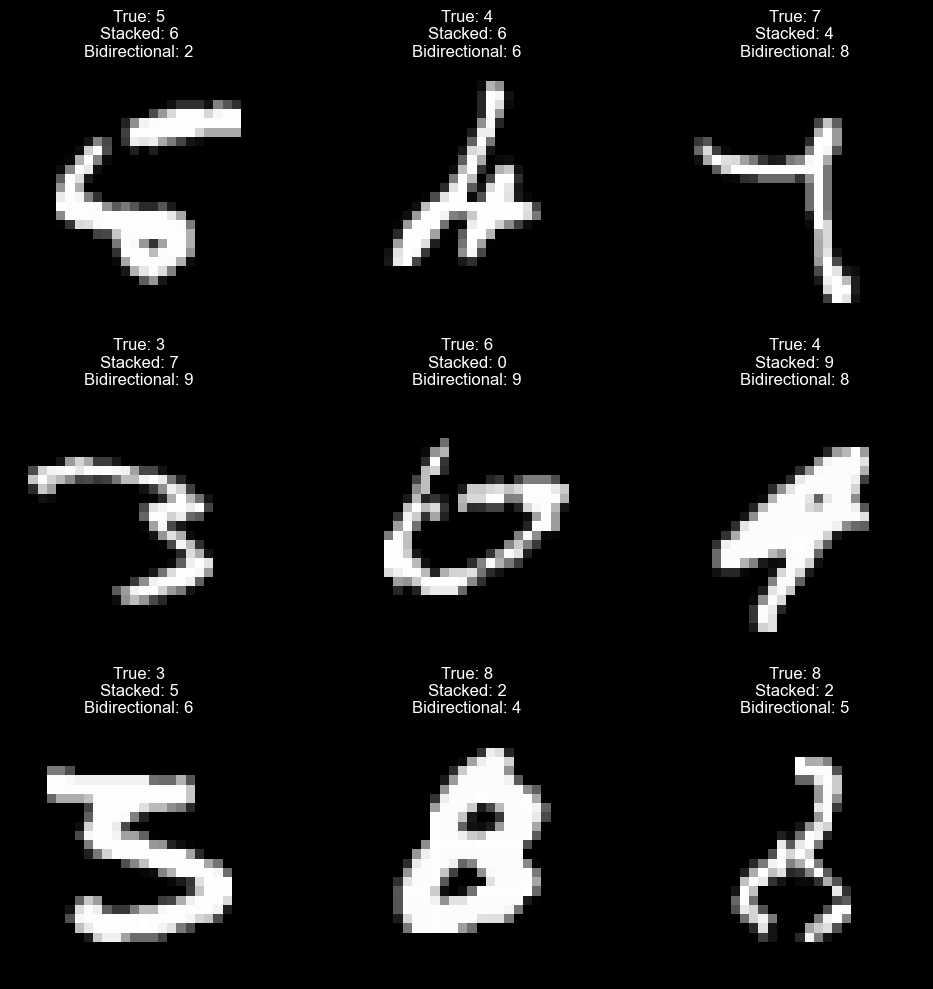

In [14]:
# for each model find the first 9 (3x3) misclassified examples and display the true label + predicted label for each model
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
misclassified_stacked = np.where(np.argmax(pred_stacked, axis=1) != y_test)[0]
misclassified_bidirectional = np.where(np.argmax(pred_bidirectional, axis=1) != y_test)[0]
for i, ax in enumerate(axes.flat):
    idx_stacked = misclassified_stacked[i]
    idx_bidirectional = misclassified_bidirectional[i]
    ax.imshow(X_test[idx_stacked], cmap='gray')
    true_label = y_test[idx_stacked]
    pred_label_stacked = np.argmax(pred_stacked[idx_stacked])
    pred_label_bidirectional = np.argmax(pred_bidirectional[idx_bidirectional])
    ax.set_title(f'True: {true_label}\nStacked: {pred_label_stacked}\nBidirectional: {pred_label_bidirectional}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# save the models
model_stacked.save('mnist_stacked_lstm_model.keras')
model_bidirectional.save('mnist_bidirectional_lstm_model.keras')

In [16]:
# load all the model and compare their test accuracies + time to predict 1example 10 example, ...
model_dense = keras.models.load_model('mnist_dense_model.keras')
model_cnn = keras.models.load_model('mnist_cnn_model.keras')
model_rnn = keras.models.load_model('mnist_rnn_model.keras')
model_gru = keras.models.load_model('mnist_gru_model.keras')
model_lstm = keras.models.load_model('mnist_lstm_model.keras')

In [17]:
# test all the models and compare their test accuracies
test_loss_dense, test_acc_dense = model_dense.evaluate(X_test, y_test)
print(f'Dense Test accuracy: {test_acc_dense:.4f}')

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test)
print(f'CNN Test accuracy: {test_acc_cnn:.4f}')

test_loss_rnn, test_acc_rnn = model_rnn.evaluate(X_test, y_test)
print(f'RNN Test accuracy: {test_acc_rnn:.4f}')

test_loss_gru, test_acc_gru = model_gru.evaluate(X_test, y_test)
print(f'GRU Test accuracy: {test_acc_gru:.4f}')

test_loss_lstm, test_acc_lstm = model_lstm.evaluate(X_test, y_test)
print(f'LSTM Test accuracy: {test_acc_lstm:.4f}')

test_loss_stacked, test_acc_stacked = model_stacked.evaluate(X_test, y_test)
print(f'Stacked LSTM Test accuracy: {test_acc_stacked:.4f}')

test_loss_bidirectional, test_acc_bidirectional = model_bidirectional.evaluate(X_test, y_test)
print(f'Bidirectional LSTM Test accuracy: {test_acc_bidirectional:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9185 - loss: 0.2817
Dense Test accuracy: 0.9185
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9849 - loss: 0.0441
CNN Test accuracy: 0.9849
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9316 - loss: 0.2298
RNN Test accuracy: 0.9316
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9087 - loss: 0.3169
GRU Test accuracy: 0.9087
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9855 - loss: 0.0484
LSTM Test accuracy: 0.9855
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9848 - loss: 0.0513
Stacked LSTM Test accuracy: 0.9848
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9360 - loss: 0.2017
Bidirectional LSTM Test accuracy: 0.9360


In [18]:
# concat test and train into X, y to test the whole dataset
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

In [19]:
# test all the models on the whole dataset and compare their accuracies
dense_acc = model_dense.evaluate(X, y)[1]
print(f'Dense Accuracy: {dense_acc:.4f}')

cnn_acc = model_cnn.evaluate(X, y)[1]
print(f'CNN Accuracy: {cnn_acc:.4f}')

rnn_acc = model_rnn.evaluate(X, y)[1]
print(f'RNN Accuracy: {rnn_acc:.4f}')

gru_acc = model_gru.evaluate(X, y)[1]
print(f'GRU Accuracy: {gru_acc:.4f}')

lstm_acc = model_lstm.evaluate(X, y)[1]
print(f'LSTM Accuracy: {lstm_acc:.4f}')

stacked_acc = model_stacked.evaluate(X, y)[1]
print(f'Stacked LSTM Accuracy: {stacked_acc:.4f}')

bidirectional_acc = model_bidirectional.evaluate(X, y)[1]
print(f'Bidirectional LSTM Accuracy: {bidirectional_acc:.4f}')

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9195 - loss: 0.2843
Dense Accuracy: 0.9195
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9870 - loss: 0.0410
CNN Accuracy: 0.9870
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.9309 - loss: 0.2386
RNN Accuracy: 0.9309
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9051 - loss: 0.3294
GRU Accuracy: 0.9051
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9911 - loss: 0.0278
LSTM Accuracy: 0.9911
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9916 - loss: 0.0282
Stacked LSTM Accuracy: 0.9916
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9337 - loss: 0.2065
Bidirectional LSTM Accuracy: 0.9337


In [20]:
# do a table of the test accuracies for all the models
import pandas as pd

model_names = ['Dense', 'CNN', 'RNN', 'GRU', 'LSTM', 'Stacked LSTM', 'Bidirectional LSTM']
test_accuracies = [dense_acc, cnn_acc, rnn_acc, gru_acc, lstm_acc, stacked_acc, bidirectional_acc]

results_df = pd.DataFrame({'Model': model_names, 'Accuracy': test_accuracies})
results_df

,Model,Accuracy
0,Dense,0.919543
1,CNN,0.986957
2,RNN,0.930929
3,GRU,0.905114
4,LSTM,0.991086
5,Stacked LSTM,0.991586
6,Bidirectional LSTM,0.933714


In [27]:
%%timeit
model_dense.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

In [21]:
%%timeit
model_cnn.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
20.3 ms ± 980 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [22]:
%%timeit
model_rnn.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
52.5 ms ± 2.95 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [23]:
%%timeit
model_gru.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
20 ms ± 1.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [24]:
%%timeit
model_lstm.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
19.8 ms ± 1.04 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [25]:
%%timeit
model_stacked.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━

In [26]:
%%timeit
model_bidirectional.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━

In [29]:
# do a table of the time taken to predict 1 example for all the models
import time

model_names = ['Dense', 'CNN', 'RNN', 'GRU', 'LSTM', 'Stacked LSTM', 'Bidirectional LSTM']
times = []
for model in [model_dense, model_cnn, model_rnn, model_gru, model_lstm, model_stacked, model_bidirectional]:
    start_time = time.time()
    model.predict(X_test[:100])
    end_time = time.time()
    times.append(end_time - start_time)
results_df['Time to Predict 100 Example (s)'] = times
results_df

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,Model,Accuracy,Time to Predict 1 Example (s),Time to Predict 100 Example (s)
0,Dense,0.919543,0.025982,0.244061
1,CNN,0.986957,0.021136,0.296293
2,RNN,0.930929,0.053857,0.410301
3,GRU,0.905114,0.020492,0.179388
4,LSTM,0.991086,0.022215,0.174330
5,Stacked LSTM,0.991586,0.019981,0.066301
6,Bidirectional LSTM,0.933714,0.025990,0.066629
